This File is for finding a valid no. for how much epochs should i train the model

From prev. experiment the lr for head is 0.0017378008365631102 and lr range for whole model is ((1.9054607491852948e-06)/10, (1.9054607491852948e-06)/4)

In [1]:
import pandas as pd
import regex as re
from fastai.vision.all import *

Varying epochs for whole model between 8 and 20 and increasing by 2

In [2]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [3]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return df['Names'][class_id]

In [4]:
signs = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = RandomSplitter(seed = 42),
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [5]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [6]:
dls = signs.dataloaders(path)

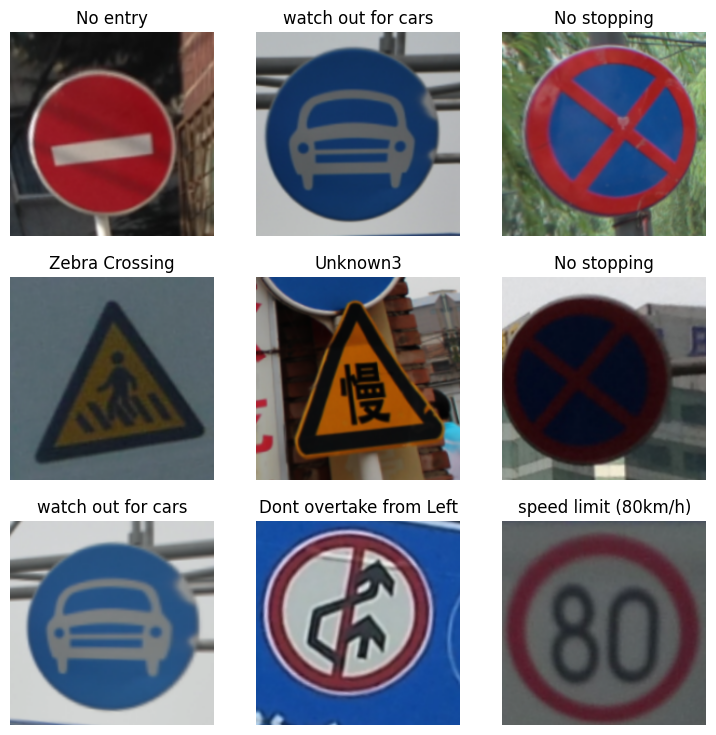

In [7]:
dls.show_batch()

In [8]:
lr_head = 0.0017378008365631102
lr_whole_model = 1.9054607491852948e-06

In [10]:
set_seed(42, reproducible = True)

In [13]:
from fastprogress.fastprogress import master_bar, progress_bar
master_bar, progress_bar = master_bar, progress_bar

In [14]:
model_2_1 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_2_1.fit_one_cycle(3, lr_head)
model_2_1.unfreeze()
model_2_1.fit_one_cycle(8, lr_max = slice(lr_whole_model/10, lr_whole_model/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.205147,0.334613,0.098795,00:19
1,0.785702,0.095938,0.030120,00:18
2,0.353629,0.079058,0.019277,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.141147,0.079220,0.018072,00:23
1,0.143512,0.076656,0.018072,00:23
2,0.140129,0.076021,0.016867,00:23
3,0.130467,0.074641,0.016867,00:23
4,0.126878,0.071464,0.016867,00:23
5,0.131013,0.072354,0.015663,00:22
6,0.132482,0.074927,0.015663,00:23
7,0.125433,0.074120,0.018072,00:23


In [15]:
model_2_2 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_2_2.fit_one_cycle(3, lr_head)
model_2_2.unfreeze()
model_2_2.fit_one_cycle(10, lr_max = slice(lr_whole_model/10, lr_whole_model/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.153101,0.315919,0.086747,00:19
1,0.773771,0.116981,0.033735,00:19
2,0.352149,0.081104,0.024096,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.129310,0.082431,0.026506,00:23
1,0.135933,0.081316,0.022892,00:23
2,0.136836,0.079624,0.022892,00:23
3,0.137611,0.078336,0.024096,00:23
4,0.128423,0.078222,0.022892,00:23
5,0.118021,0.077166,0.021687,00:23
6,0.125498,0.074151,0.022892,00:45
7,0.123375,0.077903,0.021687,00:42
8,0.126936,0.076807,0.021687,00:36
9,0.129912,0.076868,0.022892,00:39


In [16]:
model_2_3 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_2_3.fit_one_cycle(3, lr_head)
model_2_3.unfreeze()
model_2_3.fit_one_cycle(12, lr_max = slice(lr_whole_model/10, lr_whole_model/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.153146,0.337275,0.097590,00:18
1,0.797257,0.110549,0.028916,00:18
2,0.370857,0.083733,0.024096,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.139088,0.081637,0.021687,00:23
1,0.136383,0.080399,0.024096,00:23
2,0.132798,0.080036,0.024096,00:23
3,0.138592,0.077716,0.024096,00:23
4,0.131682,0.074897,0.022892,00:23
5,0.136219,0.074834,0.024096,00:23
6,0.128357,0.075263,0.024096,00:23
7,0.130357,0.074383,0.024096,00:23
8,0.132104,0.075527,0.024096,00:23
9,0.131008,0.071478,0.022892,00:23


In [17]:
model_2_4 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_2_4.fit_one_cycle(3, lr_head)
model_2_4.unfreeze()
model_2_4.fit_one_cycle(14, lr_max = slice(lr_whole_model/10, lr_whole_model/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.213836,0.342958,0.086747,00:19
1,0.792847,0.142436,0.037349,00:18
2,0.377739,0.111341,0.031325,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.154556,0.111054,0.032530,00:23
1,0.162219,0.107001,0.028916,00:23
2,0.171874,0.108087,0.030120,00:23
3,0.154167,0.107225,0.032530,00:23
4,0.149947,0.106709,0.031325,00:23
5,0.147242,0.103611,0.027711,00:23
6,0.142566,0.104781,0.028916,00:23
7,0.140657,0.100566,0.028916,00:23
8,0.145455,0.103969,0.028916,00:23
9,0.136818,0.099773,0.027711,00:23


In [18]:
model_2_5 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_2_5.fit_one_cycle(3, lr_head)
model_2_5.unfreeze()
model_2_5.fit_one_cycle(16, lr_max = slice(lr_whole_model/10, lr_whole_model/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.205459,0.373169,0.101205,00:19
1,0.813602,0.134041,0.043373,00:18
2,0.371085,0.099696,0.037349,00:19


epoch,train_loss,valid_loss,error_rate,time
0,0.139522,0.101064,0.034940,00:23
1,0.141801,0.098580,0.036145,00:23
2,0.141080,0.098680,0.032530,00:23
3,0.133177,0.095210,0.032530,00:34
4,0.127806,0.094853,0.032530,00:40
5,0.127277,0.093540,0.028916,00:42
6,0.126587,0.095023,0.032530,00:40
7,0.126591,0.092666,0.028916,00:40
8,0.120519,0.090172,0.027711,00:43
9,0.123888,0.089714,0.027711,00:33


In [19]:
model_2_6 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_2_6.fit_one_cycle(3, lr_head)
model_2_6.unfreeze()
model_2_6.fit_one_cycle(18, lr_max = slice(lr_whole_model/10, lr_whole_model/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.168842,0.324238,0.091566,00:19
1,0.789760,0.111411,0.037349,00:18
2,0.365676,0.085442,0.027711,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.151966,0.083002,0.027711,00:23
1,0.148843,0.079433,0.026506,00:23
2,0.149445,0.082622,0.026506,00:23
3,0.153798,0.082382,0.026506,00:23
4,0.140482,0.082129,0.025301,00:23
5,0.146035,0.079174,0.024096,00:23
6,0.140563,0.076693,0.022892,00:23
7,0.134572,0.078600,0.022892,00:23
8,0.131848,0.075654,0.024096,00:23
9,0.127617,0.077076,0.021687,00:23


In [20]:
model_2_7 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_2_7.fit_one_cycle(3, lr_head)
model_2_7.unfreeze()
model_2_7.fit_one_cycle(20, lr_max = slice(lr_whole_model/10, lr_whole_model/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.189511,0.348762,0.093976,00:19
1,0.777059,0.112539,0.039759,00:18
2,0.349319,0.088326,0.030120,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.133872,0.089275,0.027711,00:23
1,0.128890,0.089170,0.028916,00:23
2,0.124993,0.089541,0.026506,00:23
3,0.135916,0.091187,0.028916,00:23
4,0.133318,0.085689,0.027711,00:23
5,0.119774,0.084393,0.026506,00:23
6,0.124342,0.085722,0.025301,00:23
7,0.120716,0.082301,0.024096,00:23
8,0.117250,0.078291,0.024096,00:24
9,0.116129,0.078990,0.022892,00:23


So as we can see that no. 8 is the best no. for no. of epochs as it is taking less time so we fix 8 to be no. of epochs for further experiments

In [21]:
dls.bs

64